## Pedersen (Senseval2) validation - features

This notebook valudates the use of the semantic features for analyzing polysemy.

Now that we know feature vector clusters reflect sense distinctions, lets find out which features show up for different clusters

## 0. Preamble

In [1]:
import nltk
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, v_measure_score, normalized_mutual_info_score, homogeneity_score, completeness_score
import matplotlib.pyplot as plt
import seaborn as sns

print("All imports successful!")

All imports successful!


## 1. Load Data

In [2]:
 # load pedersen sense-tagged corpus
fileids = [
    'hard.pos',
    'line.pos',
    'interest.pos',
    'serve.pos',
]
root = '/home/gsc685/data/pedersen_sense_tagged/'
corpus = nltk.corpus.reader.senseval.SensevalCorpusReader(root, fileids=fileids)
instances = corpus.instances()

print("first row of data")
print(instances[0])
print("number of instances:", len(instances))
words = ' '.join([word for (word, pos) in instances[0].context])
print("words in first sentence: ", words)

first row of data
SensevalInstance(word='hard-a', position=20, context=[('``', '``'), ('he', 'PRP'), ('may', 'MD'), ('lose', 'VB'), ('all', 'DT'), ('popular', 'JJ'), ('support', 'NN'), (',', ','), ('but', 'CC'), ('someone', 'NN'), ('has', 'VBZ'), ('to', 'TO'), ('kill', 'VB'), ('him', 'PRP'), ('to', 'TO'), ('defeat', 'VB'), ('him', 'PRP'), ('and', 'CC'), ('that', 'DT'), ("'s", 'VBZ'), ('hard', 'JJ'), ('to', 'TO'), ('do', 'VB'), ('.', '.'), ("''", "''")], senses=('HARD1',))
number of instances: 15225
words in first sentence:  `` he may lose all popular support , but someone has to kill him to defeat him and that 's hard to do . ''


In [3]:
# convert to pandas dataframe
# you want data in this format: word | word_form | sentence | pos | position | sense
def get_data(instances):
    data = []
    for instance in instances:
        try:
            word = instance.word
            word_form = instance.context[instance.position][0]
            try:
                sentence = ' '.join([word for (word, pos) in instance.context])
            except:
                stripped_instance = [item for item in instance.context if isinstance(item, tuple)]
                sentence = ' '.join([word for (word, pos) in stripped_instance])
            pos = instance.context[instance.position][1]
            position = instance.position
            sense = instance.senses[0]
            data.append((word, word_form, sentence, pos, position, sense))
        except Exception as e:
            print(f"Error processing instance: {e}")
            continue
    return data

data = get_data(instances)
print("data in this format: word | word_form | sentence | pos | position | sense")
print(data[0])
pedersen_df = pd.DataFrame(data, columns=['word', 'word_form', 'sentence', 'pos', 'position', 'sense'])

pedersen_df.head(5)

data in this format: word | word_form | sentence | pos | position | sense
('hard-a', 'hard', "`` he may lose all popular support , but someone has to kill him to defeat him and that 's hard to do . ''", 'JJ', 20, 'HARD1')


,word,word_form,sentence,pos,position,sense
0,hard-a,hard,"`` he may lose all popular support , but someo...",JJ,20,HARD1
1,hard-a,hard,clever white house `` spin doctors '' are havi...,JJ,10,HARD1
2,hard-a,hard,i find it hard to believe that the sacramento ...,JJ,3,HARD1
3,hard-a,hard,now when you get bad credit data or are confus...,JJ,15,HARD1
4,hard-a,harder,'a great share of responsibility for this nati...,JJ,66,HARD1


In [4]:
# note: features.token_id corresponds to the index column of the pedersen_df
# add the index as token_id in pedersen_df
pedersen_df = pedersen_df.reset_index().rename(columns={'index': 'token_id'})

In [5]:
#sample five tokens from each sense of interest
pedersen_df_sampled = pedersen_df.groupby('sense').apply(lambda x: x.sample(n=5, random_state=42)).reset_index(drop=True)
#pedersen_df_sampled[pedersen_df_sampled['word'] == 'interest-n']
pedersen_df_sampled[pedersen_df_sampled['word'] == 'serve-v']
#pedersen_df_sampled[pedersen_df_sampled['word'] == 'hard-a']

/tmp/ipykernel_3599773/2927336824.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pedersen_df_sampled = pedersen_df.groupby('sense').apply(lambda x: x.sample(n=5, random_state=42)).reset_index(drop=True)


,token_id,word,word_form,sentence,pos,position,sense
15,11876,serve-v,serve,heat . serve steaming hot in demitasse cups as...,VB,2,SERVE10
16,12296,serve-v,serves,cover and simmer over low heat for about 1 hou...,VBZ,11,SERVE10
17,11379,serve-v,served,i grew up on a farm in the '30s when you butch...,VBD,41,SERVE10
18,11753,serve-v,serves,garnish with chopped parsley . serves 4 to 6 .,VBZ,5,SERVE10
19,11844,serve-v,served,the french phrase hors d 'oeuvre is an idiomat...,VBD,31,SERVE10
20,12869,serve-v,serve,"they identify themselves with the poor , and t...",VB,23,SERVE12
21,13627,serve-v,served,walcott was his chief dependence . he had serv...,VBD,8,SERVE12
22,13375,serve-v,serve,""" this is just a personal investment of his . ...",VB,28,SERVE12
23,13853,serve-v,serving,"three years after marco polo arrived home , th...",VBG,21,SERVE12
24,13245,serve-v,serve,every individual mentioned in the book was a r...,VB,20,SERVE12


## 2. Load Features and Perform regression analysis

In [6]:
# Dictionary to store results
validation_results = []

# Lemmas to validate
lemmas = ['hard-a', 'interest-n', 'line-n', 'serve-v']

for lemma in lemmas:
    print(f"\n{'='*60}")
    print(f"Processing: {lemma}")
    print(f"{'='*60}")
    
    # 1. Load features for this lemma
    features_path = f'/home/gsc685/data/features/senseval2/{lemma}_feature_vectors_roberta_buchanan_layer7.csv'
    features_df = pd.read_csv(features_path)
    print(f"Loaded {len(features_df)} feature rows")

    # 1.5 Drop infrequent features (occurring in less than 5 tokens)
    print(f"Rows before dropping infrequent features: {len(features_df)}")
    with open('/home/gsc685/data/buchanan_ratings/low_frequency_features_<5.txt', 'r') as f:
        infrequent_features = [line.strip() for line in f.readlines()]
    print(f"Dropping {len(infrequent_features)} infrequent features")
    features_df = features_df[~features_df['feature'].isin(infrequent_features)].copy()
    print(f"Remaining feature rows after dropping infrequent features: {len(features_df)}")
    
    
    # 2. Get subset of pedersen_df for this lemma
    lemma_data = pedersen_df[pedersen_df['word'] == lemma].copy()
    print(f"Found {len(lemma_data)} instances in pedersen_df")
    
    # 3. Get number of senses for this lemma
    n_senses = lemma_data['sense'].nunique()
    sense_counts = lemma_data.groupby('sense').size()
    print(f"Number of gold senses: {n_senses}")
    print(f"Sense distribution:\n{sense_counts}")
    
    # 4. Transform features into feature vectors (pivot wide format)
    # Each row should be a token_id with all feature values as columns
    print(f"\nTransforming to feature vectors...")
    
    # # Check if token_id exists, otherwise create it from index
    # if 'token_id' not in features_df.columns:
    #     # Assuming features are grouped by instance (each instance has 3981 features)
    #     features_df['token_id'] = features_df.index // 3981
    
    # Pivot to wide format: rows=token_id, columns=feature, values=predicted_value
    feature_matrix = features_df.pivot(index='token_id', columns='feature', values='predicted_value')
    print(f"Feature matrix shape: {feature_matrix.shape}")
    
    # Handle any NaN values
    # feature_matrix = feature_matrix.fillna(0)
    
    # 5. Add token_id to lemma_data if not present
    #if 'token_id' not in lemma_data.columns:
    #    lemma_data['token_id'] = range(len(lemma_data))
    
    # Ensure we have matching data
    # Keep only tokens that appear in both datasets
    common_token_ids = set(feature_matrix.index) & set(lemma_data['token_id'])
    print(f"Common tokens between features and gold data: {len(common_token_ids)}")
    
    # Filter both dataframes
    feature_matrix_filtered = feature_matrix.loc[list(common_token_ids)].sort_index()
    lemma_data_filtered = lemma_data[lemma_data['token_id'].isin(common_token_ids)].sort_values('token_id')

    # 6. Regressions - for each gold sense cluster, find most predictive features
    from sklearn.linear_model import LogisticRegression
    from scipy import stats

    # Get unique senses for this lemma
    senses = lemma_data_filtered['sense'].unique()
    
    # Store regression results
    regression_results = []
    
    for sense in senses:
        print(f"\nAnalyzing features for sense: {sense}")
        
        # Create binary target: 1 if token belongs to this sense, 0 otherwise
        y = (lemma_data_filtered['sense'] == sense).astype(int).values
        
        # For each feature, run a simple logistic regression
        for feature_name in feature_matrix_filtered.columns:
            # Get feature values
            X = feature_matrix_filtered[feature_name].values.reshape(-1, 1)
            
            # Check if feature has variance
            if X.std() == 0:
                continue
            
            # Fit logistic regression
            try:
                lr = LogisticRegression(random_state=42, max_iter=1000)
                lr.fit(X, y)
                
                # Get coefficient and score
                coef = lr.coef_[0][0]
                score = lr.score(X, y)
                
                # Store result
                regression_results.append({
                    'lemma': lemma,
                    'sense': sense,
                    'feature': feature_name,
                    'coefficient': coef,
                    'accuracy': score,
                    'n_samples': len(y),
                    'n_positive': y.sum()
                })
            except Exception as e:
                print(f"Error with feature {feature_name}: {e}")
                continue
    
    # Convert results to dataframe for this lemma
    if regression_results:
        lemma_results_df = pd.DataFrame(regression_results)
        
        # For each sense, show top 10 most predictive features (by absolute coefficient)
        print(f"\n{'='*60}")
        print(f"Top 10 features for each sense of {lemma}:")
        print(f"{'='*60}")
        
        for sense in senses:
            sense_results = lemma_results_df[lemma_results_df['sense'] == sense].copy()
            sense_results['abs_coef'] = sense_results['coefficient'].abs()
            top_features = sense_results.nlargest(10, 'abs_coef')
            
            print(f"\nSense: {sense} (n={top_features.iloc[0]['n_positive']})")
            print(top_features[['feature', 'coefficient', 'accuracy']].to_string(index=False))
        
        # Save results
        validation_results.append(lemma_results_df)



Processing: hard-a
Loaded 16891383 feature rows
Rows before dropping infrequent features: 16891383
Dropping 1941 infrequent features
Remaining feature rows after dropping infrequent features: 8655720
Found 4333 instances in pedersen_df
Number of gold senses: 3
Sense distribution:
sense
HARD1    3455
HARD2     502
HARD3     376
dtype: int64

Transforming to feature vectors...
Feature matrix shape: (4243, 2040)
Common tokens between features and gold data: 4243

Analyzing features for sense: HARD1

Analyzing features for sense: HARD2

Analyzing features for sense: HARD3

Top 10 features for each sense of hard-a:

Sense: HARD1 (n=3394)
   feature  coefficient  accuracy
    silent    15.049826  0.806269
    expert   -14.938335  0.804148
      code    13.649233  0.800377
individual    13.576549  0.800377
  conclude    13.563517  0.801084
    legend   -13.472960  0.800141
     grill    13.340713  0.800141
   secrete    13.073596  0.800613
  backpack    12.890621  0.801084
     patch    12.8

## 3. Combine and Save Results

In [ ]:
# Combine all results into one dataframe
all_results = pd.concat(validation_results, ignore_index=True)

print(f"Total regression results: {len(all_results)}")
print(f"\nUnique lemmas: {all_results['lemma'].unique()}")
print(f"Unique senses: {all_results['sense'].nunique()}")
print(f"Unique features analyzed: {all_results['feature'].nunique()}")

# Save to CSV
output_path = '/home/gsc685/acl_metapragmatics/pedersen_validation/pedersen_feature_regression_results.csv'
all_results.to_csv(output_path, index=False)
print(f"\nResults saved to: {output_path}")

all_results.head(10)

Total regression results: 38760

Unique lemmas: ['hard-a' 'interest-n' 'line-n' 'serve-v']
Unique senses: 19
Unique features analyzed: 2040

Results saved to: /home/gsc685/acl_metapragmatics/pedersen_validation/pedersen_feature_regression_results.csv


,lemma,sense,feature,coefficient,accuracy,n_samples,n_positive
0,hard-a,HARD1,FALSE,4.951034,0.799906,4243,3394
1,hard-a,HARD1,TRUE,-1.488918,0.802027,4243,3394
2,hard-a,HARD1,able,1.510277,0.809569,4243,3394
3,hard-a,HARD1,above,-0.893804,0.799906,4243,3394
4,hard-a,HARD1,absorb,-3.360207,0.799906,4243,3394
5,hard-a,HARD1,abundance,5.969932,0.799906,4243,3394
6,hard-a,HARD1,accent,-12.171685,0.802498,4243,3394
7,hard-a,HARD1,accept,0.264976,0.799906,4243,3394
8,hard-a,HARD1,accessory,1.438484,0.805798,4243,3394
9,hard-a,HARD1,accident,-1.442348,0.809333,4243,3394


## 4. Top Features Summary for Each Sense

In [ ]:
# For each lemma and sense, show top 20 features by absolute coefficient
top_features_summary = []

for lemma in all_results['lemma'].unique():
    lemma_data = all_results[all_results['lemma'] == lemma]
    
    for sense in lemma_data['sense'].unique():
        sense_data = lemma_data[lemma_data['sense'] == sense].copy()
        sense_data['abs_coef'] = sense_data['coefficient'].abs()
        
        # Get top 20 features
        top_20 = sense_data.nlargest(20, 'coefficient')
        
        top_features_summary.append({
            'lemma': lemma,
            'sense': sense,
            'top_features': ', '.join(top_20['feature'].tolist()[:10]),  # Store top 10 as string
            'n_samples': top_20.iloc[0]['n_positive']
        })

top_features_df = pd.DataFrame(top_features_summary)
print("Top 10 features for each sense (comma-separated):")
top_features_df

Top 10 features for each sense (comma-separated):


,lemma,sense,top_features,n_samples
0,hard-a,HARD1,"silent, expert, code, individual, conclude, le...",3394
1,hard-a,HARD2,"silent, expert, accent, backpack, guideline, c...",484
2,hard-a,HARD3,"calculate, silent, pan, expert, pound, conclud...",365
3,interest-n,interest_6,"preserve, fiction, trait, elephant, interrogat...",1214
4,interest-n,interest_5,"glue, jar, fiction, trait, bang, preserve, mor...",475
5,interest-n,interest_1,"beg, elephant, demand, code, expert, secrete, ...",355
6,interest-n,interest_3,"continue, intestine, relieve, discuss, differe...",65
7,interest-n,interest_4,"seal, relieve, intestine, different, option, a...",167
8,interest-n,interest_2,"surprise, wonder, awe, solution, challenge, pu...",11
9,line-n,cord,"carpentry, rope, pound, appreciate, here, plum...",317


## 5. Visualization: Top Features by Sense

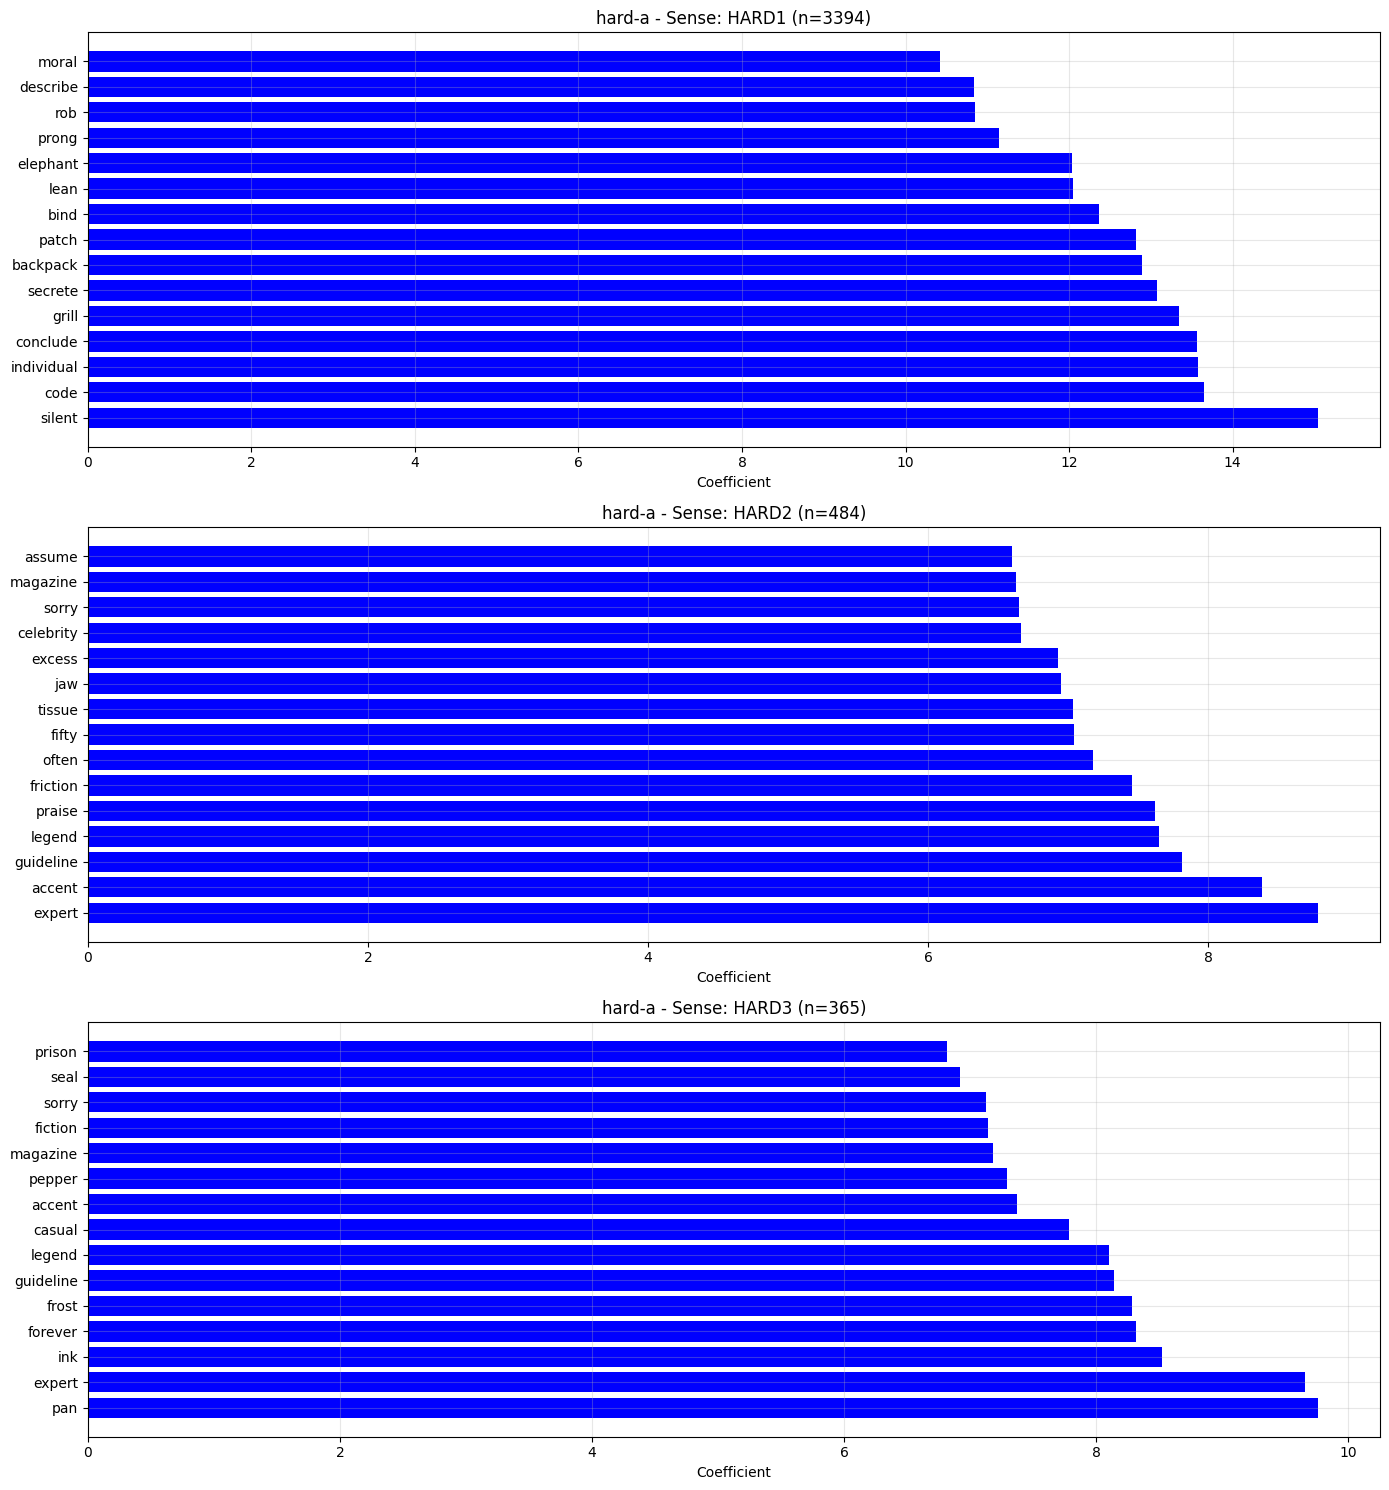

Saved visualization for hard-a


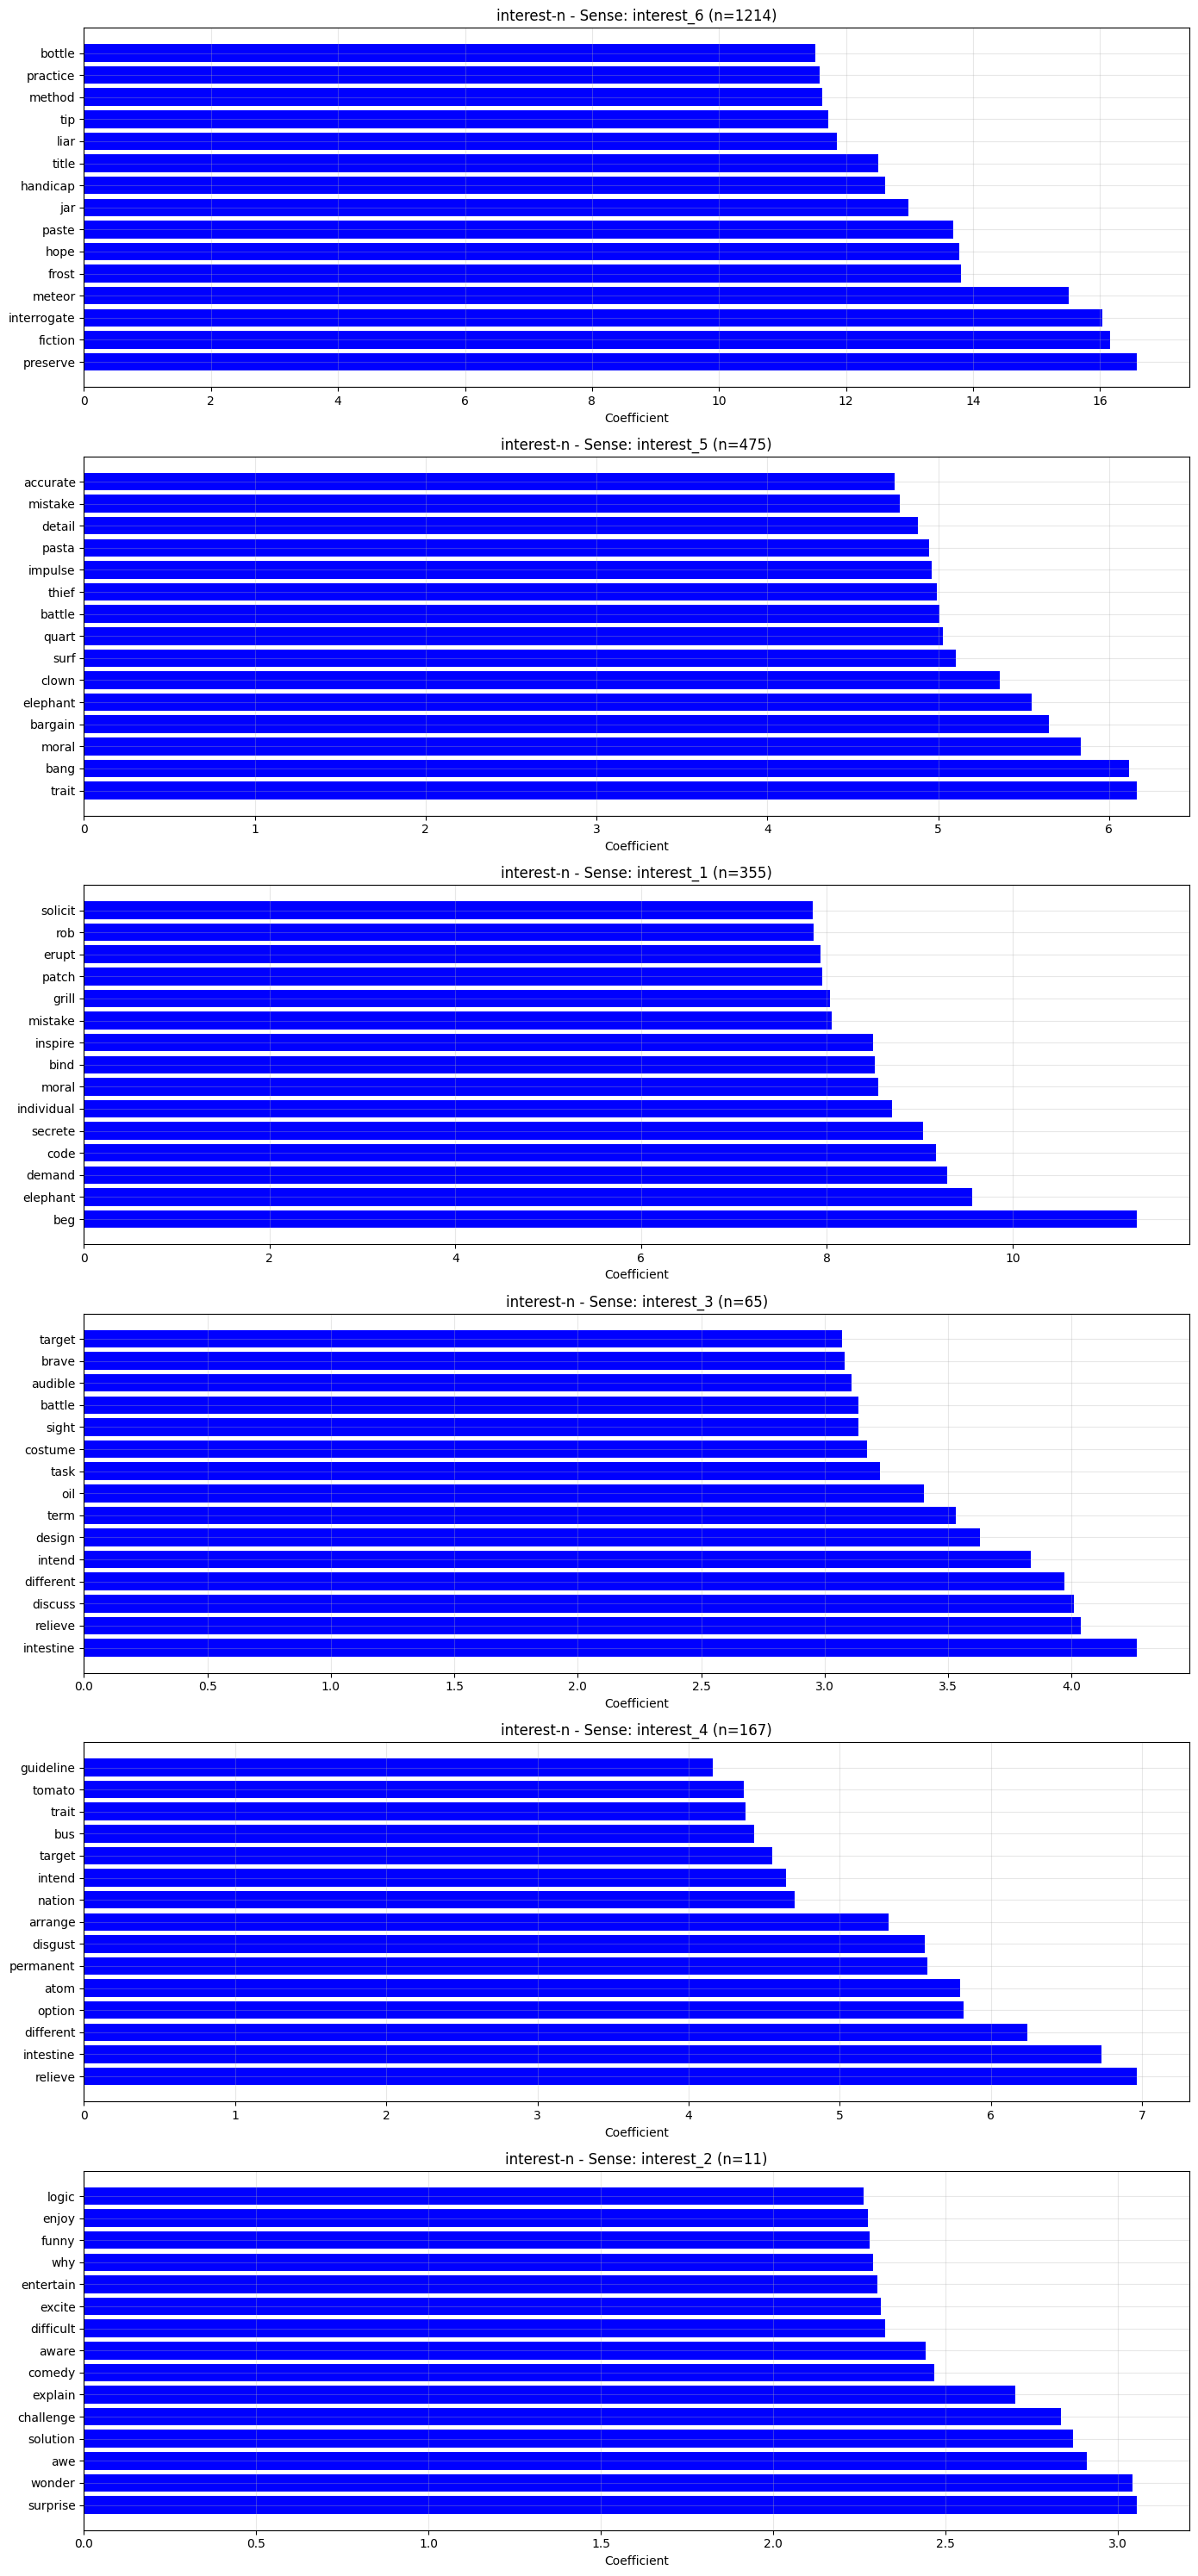

Saved visualization for interest-n


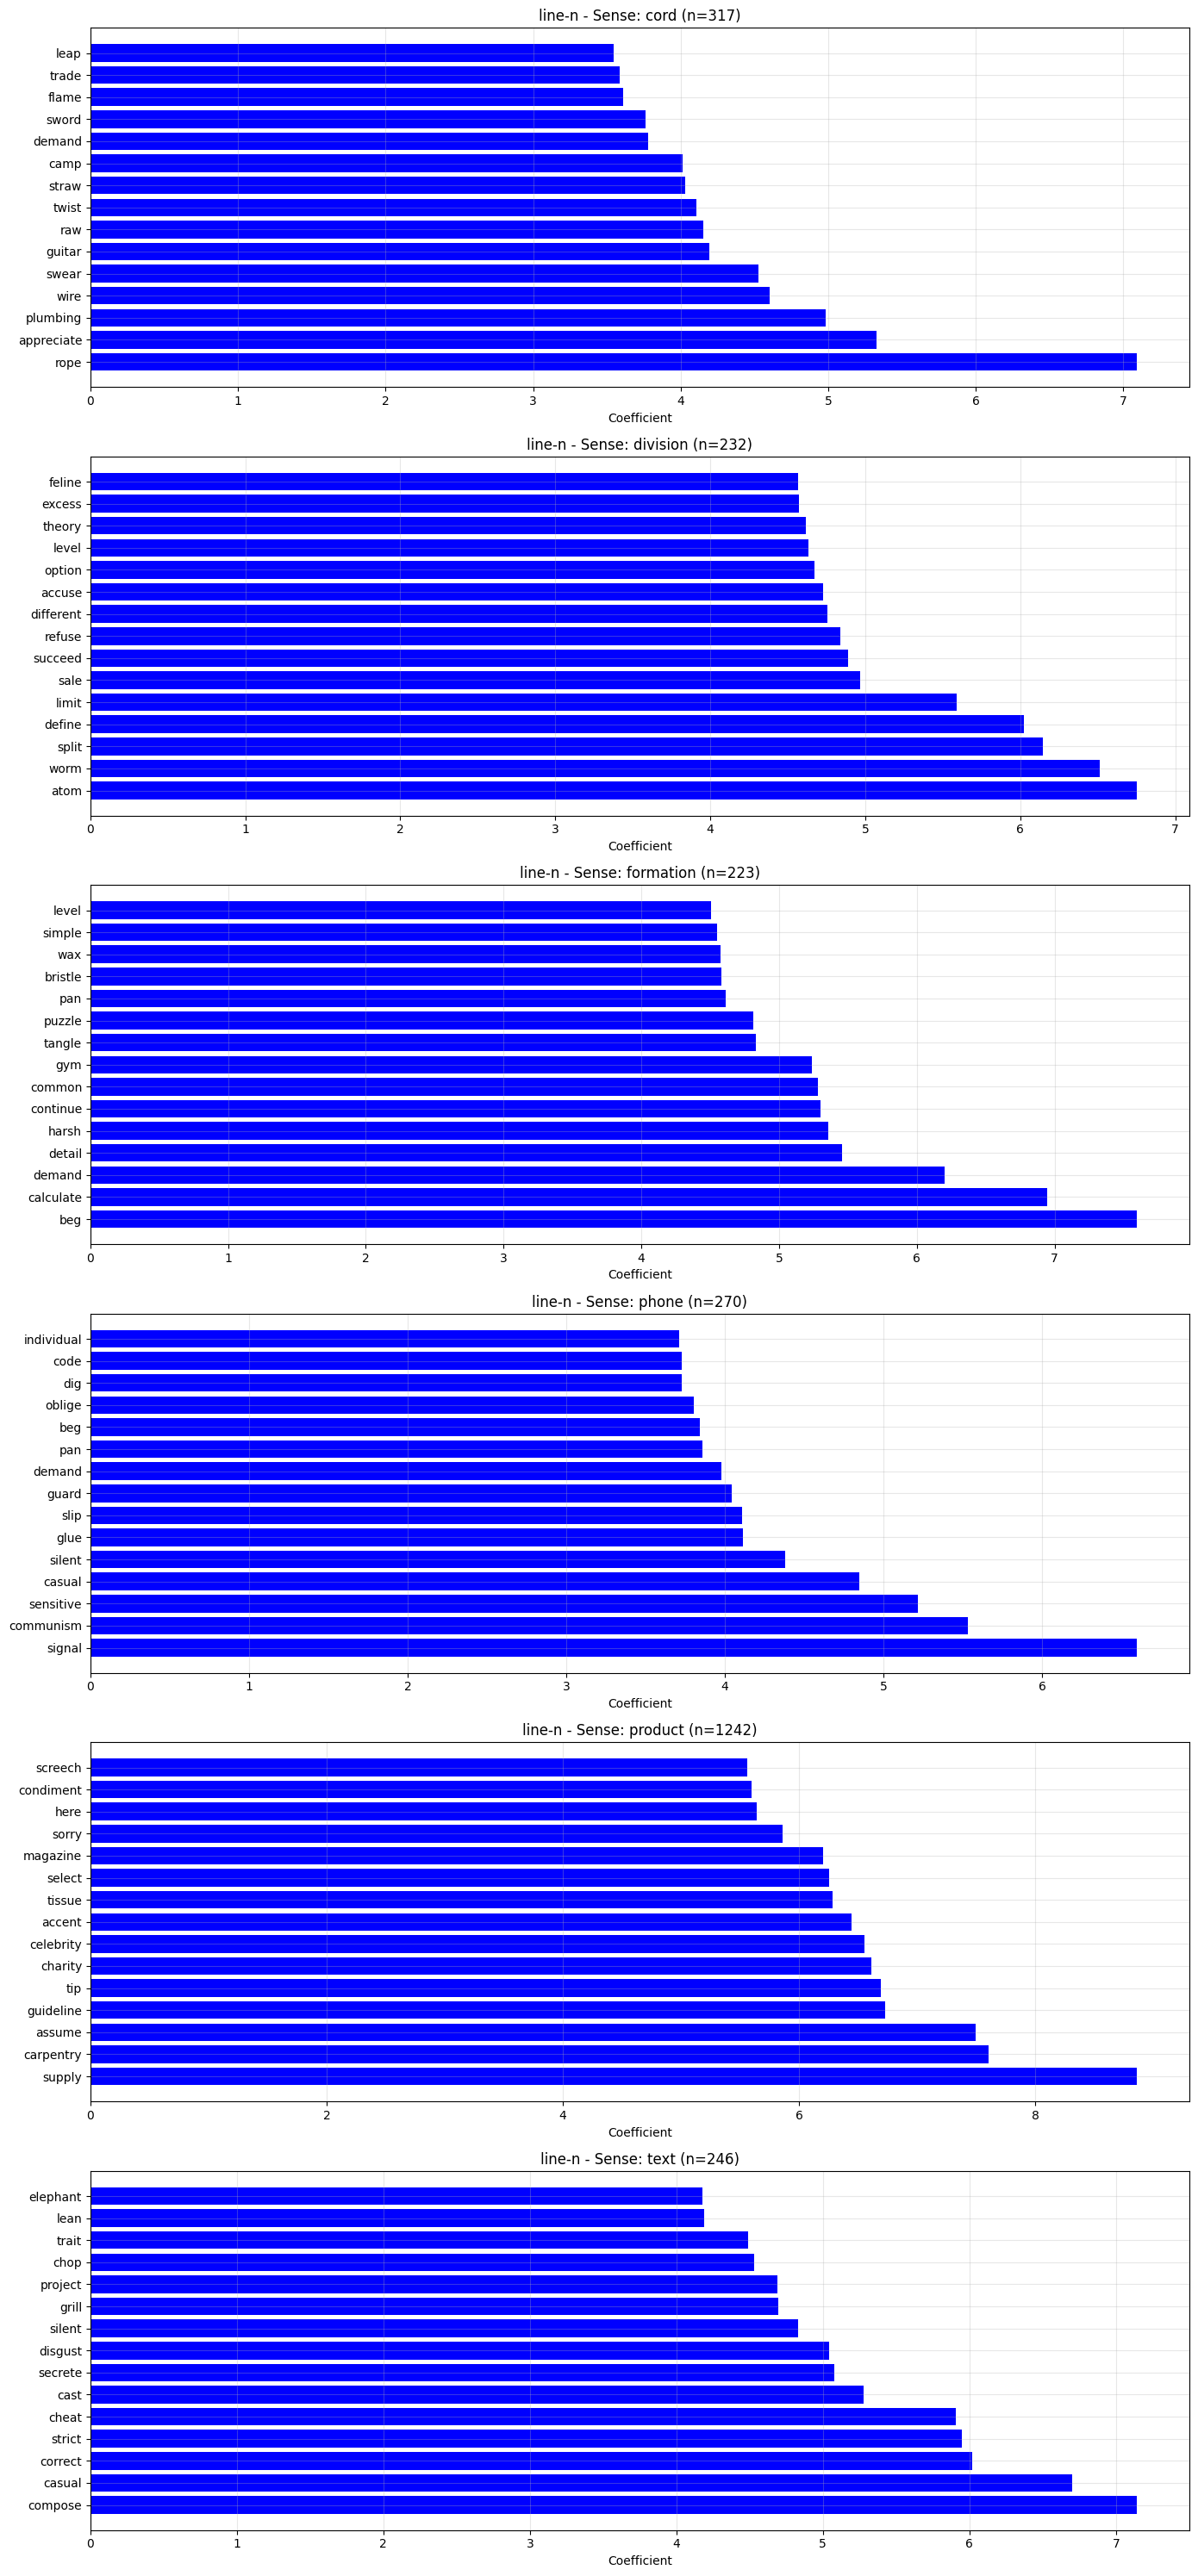

Saved visualization for line-n


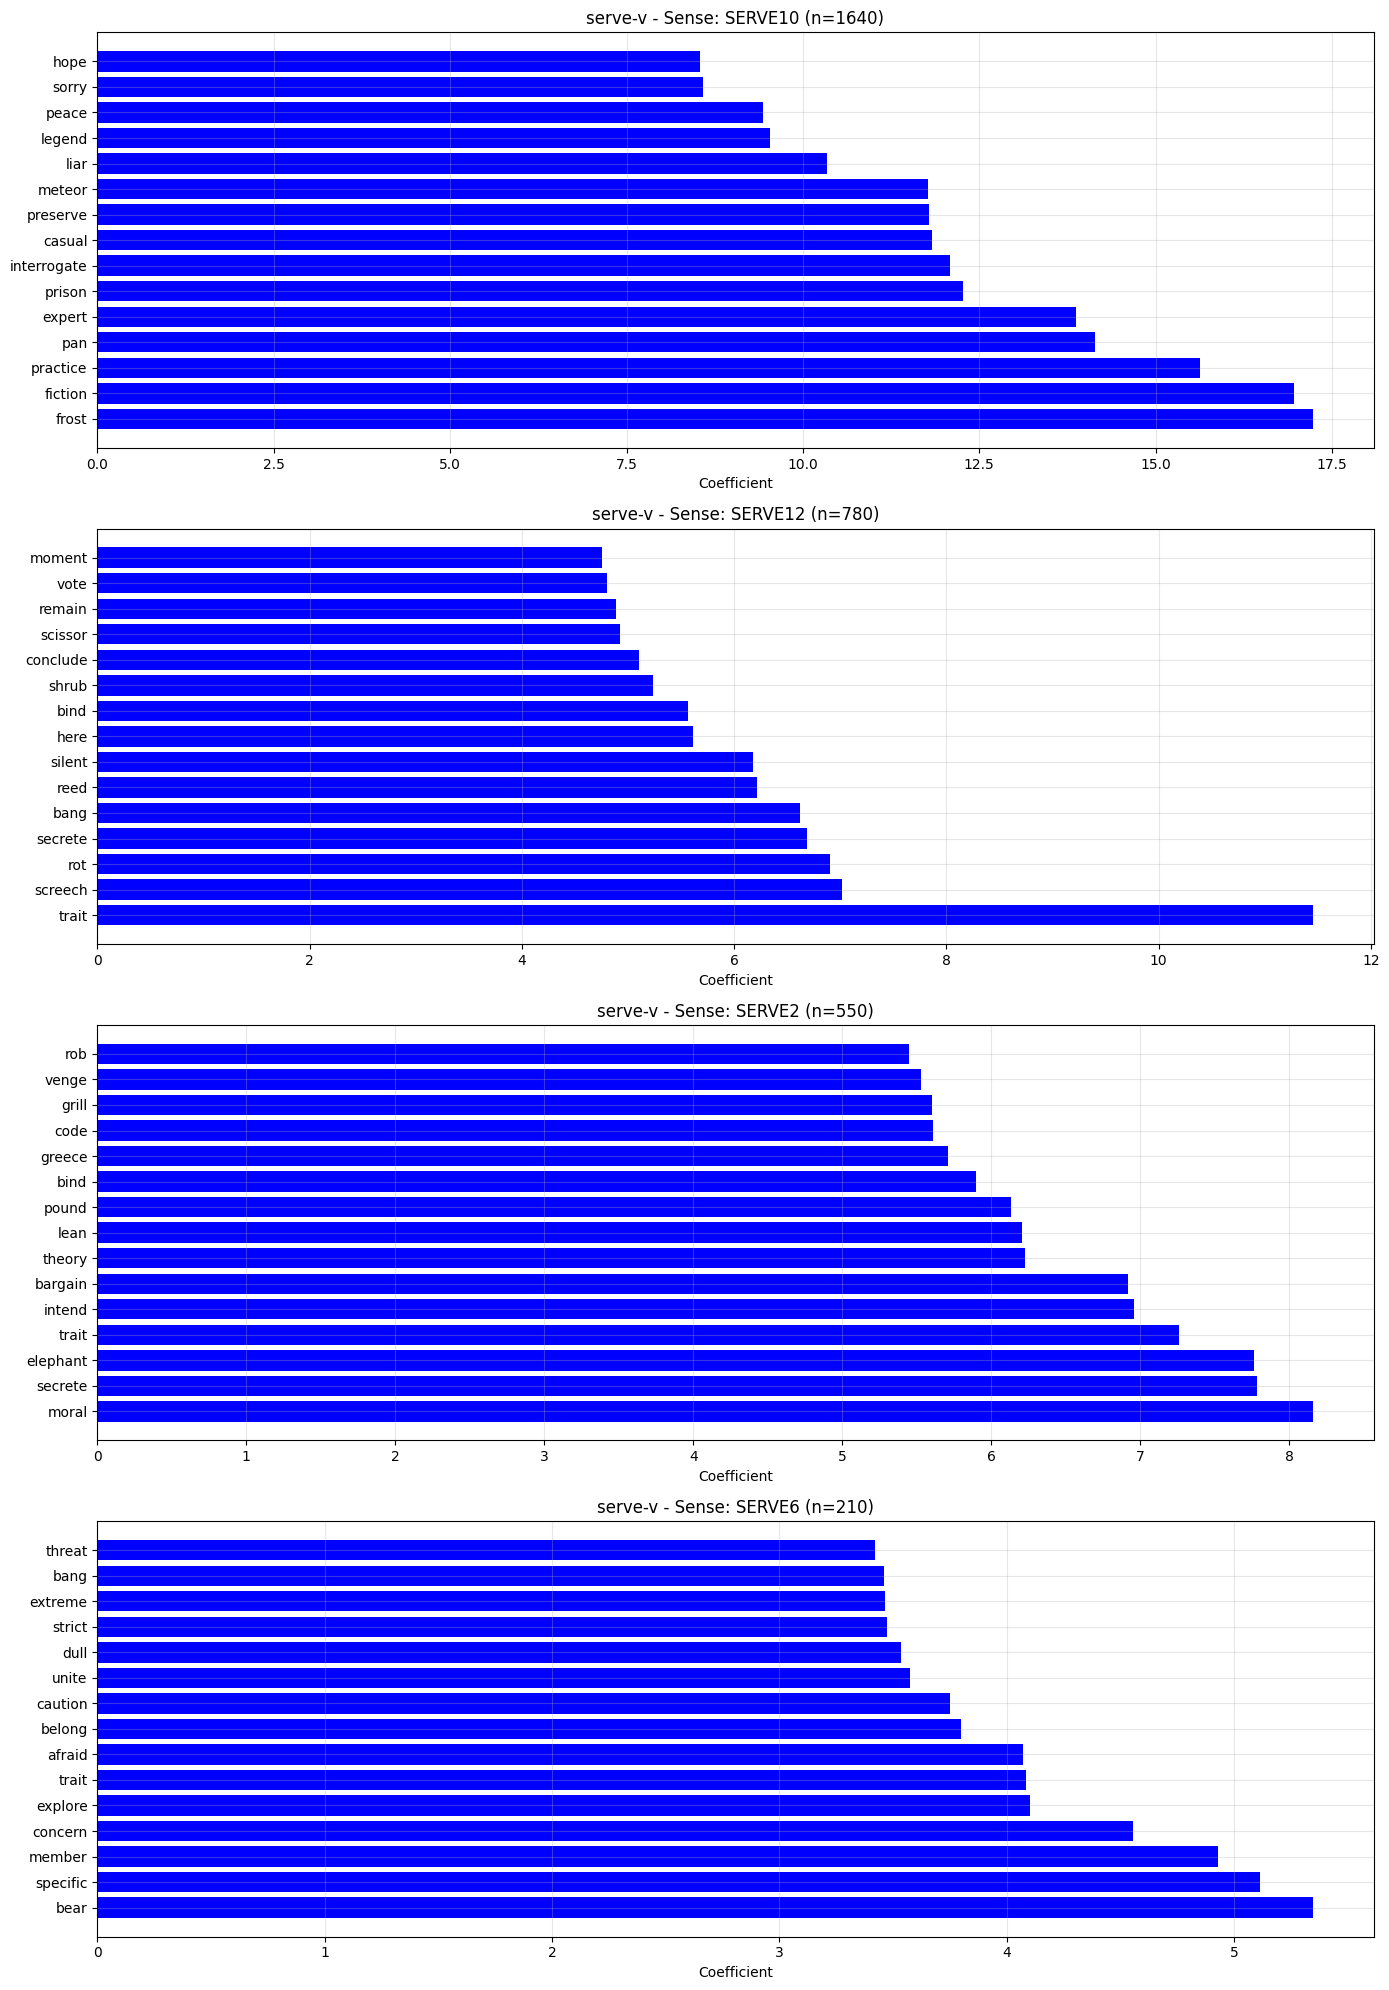

Saved visualization for serve-v


In [ ]:
# Create visualizations for each lemma
for lemma in all_results['lemma'].unique():
    lemma_data = all_results[all_results['lemma'] == lemma]
    senses = lemma_data['sense'].unique()
    
    # Create a figure with subplots for each sense
    n_senses = len(senses)
    fig, axes = plt.subplots(n_senses, 1, figsize=(14, 5*n_senses))
    
    if n_senses == 1:
        axes = [axes]
    
    for idx, sense in enumerate(senses):
        sense_data = lemma_data[lemma_data['sense'] == sense].copy()
        sense_data['abs_coef'] = sense_data['coefficient'].abs()
        
        # Get top 15 features
        top_15 = sense_data.nlargest(15, 'coefficient')
        
        # Create bar plot
        ax = axes[idx]
        colors = ['red' if c < 0 else 'blue' for c in top_15['coefficient']]
        ax.barh(range(len(top_15)), top_15['coefficient'], color=colors)
        ax.set_yticks(range(len(top_15)))
        ax.set_yticklabels(top_15['feature'])
        ax.set_xlabel('Coefficient')
        ax.set_title(f'{lemma} - Sense: {sense} (n={top_15.iloc[0]["n_positive"]})')
        ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'/home/gsc685/acl_metapragmatics/pedersen_validation/{lemma}_top_features_by_sense.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"Saved visualization for {lemma}")

## 6. Features with Highest Predictive Accuracy

In [ ]:
# For each sense, find features with highest predictive accuracy
print("="*80)
print("TOP 10 MOST PREDICTIVE FEATURES BY ACCURACY FOR EACH SENSE")
print("="*80)

for lemma in all_results['lemma'].unique():
    lemma_data = all_results[all_results['lemma'] == lemma]
    
    print(f"\n{lemma.upper()}")
    print("-"*80)
    
    for sense in lemma_data['sense'].unique():
        sense_data = lemma_data[lemma_data['sense'] == sense].copy()
        
        # Get top 10 by accuracy
        top_acc = sense_data.nlargest(10, 'accuracy')
        
        print(f"\nSense: {sense} (n={top_acc.iloc[0]['n_positive']})")
        print(top_acc[['feature', 'coefficient', 'accuracy']].to_string(index=False))

# Save top accuracy features to CSV
top_accuracy_features = []

for lemma in all_results['lemma'].unique():
    lemma_data = all_results[all_results['lemma'] == lemma]
    
    for sense in lemma_data['sense'].unique():
        sense_data = lemma_data[lemma_data['sense'] == sense].copy()
        top_10 = sense_data.nlargest(10, 'accuracy')
        
        for idx, row in top_10.iterrows():
            top_accuracy_features.append({
                'lemma': lemma,
                'sense': sense,
                'rank': list(range(1, 11))[list(top_10.index).index(idx)],
                'feature': row['feature'],
                'coefficient': row['coefficient'],
                'accuracy': row['accuracy'],
                'n_samples': row['n_positive']
            })

top_acc_df = pd.DataFrame(top_accuracy_features)
top_acc_df.to_csv('/home/gsc685/acl_metapragmatics/pedersen_validation/pedersen_top_accuracy_features.csv', index=False)
print("\n" + "="*80)
print("Top accuracy features saved to: pedersen_validation/pedersen_top_accuracy_features.csv")

TOP 10 MOST PREDICTIVE FEATURES BY ACCURACY FOR EACH SENSE

HARD-A
--------------------------------------------------------------------------------

Sense: HARD1 (n=3394)
  feature  coefficient  accuracy
challenge     2.102445  0.848928
    sweet    -0.763729  0.847278
   spread    -3.890004  0.844921
    cloth    -0.450445  0.843978
      bee    -1.560903  0.840443
   create    -1.138202  0.839500
      fat    -1.612400  0.837851
  problem     2.159756  0.835965
   pillow    -1.129773  0.833137
  observe    -2.021309  0.831487

Sense: HARD2 (n=484)
feature  coefficient  accuracy
observe     1.962498  0.901956
 person     0.265737  0.895357
 reflex     2.570180  0.890879
    job     0.560987  0.890172
  wrist     1.272258  0.889701
  apply     1.308640  0.888994
  trash     1.179538  0.888287
 vision     0.875972  0.888051
  blink     3.457783  0.887815
    pen     1.736093  0.887815

Sense: HARD3 (n=365)
 feature  coefficient  accuracy
   cloth     0.656063  0.938723
   sweet     0.86

## 7. Predicted Clusters Analysis (K-means)

In [ ]:
lemmas = ['hard-a', 'interest-n', 'line-n', 'serve-v']

# Dictionary to store results for predicted clusters
predicted_validation_results = []
cluster_samples = []

# K values for each lemma
k_values = {
    'hard-a': 3,
    'interest-n': 6,
    'line-n': 7,
    'serve-v': 6
}

for lemma in lemmas:
    print(f"\n{'='*60}")
    print(f"Processing: {lemma} (k={k_values[lemma]})")
    print(f"{'='*60}")
    
    # 1. Load features for this lemma
    features_path = f'/home/gsc685/data/features/senseval2/{lemma}_feature_vectors_roberta_buchanan_layer7.csv'
    features_df = pd.read_csv(features_path)
    print(f"Loaded {len(features_df)} feature rows")

    # 1.5 Remove infrequent features (occurring in less than 5 tokens)
    print(f"Rows before dropping infrequent features: {len(features_df)}")
    with open('/home/gsc685/data/buchanan_ratings/low_frequency_features_<5.txt', 'r') as f:
        infrequent_features = [line.strip() for line in f.readlines()]
    print(f"Dropping {len(infrequent_features)} infrequent features")
    features_df = features_df[~features_df['feature'].isin(infrequent_features)].copy()
    print(f"Remaining feature rows after dropping infrequent features: {len(features_df)}")
    
    # 2. Get subset of pedersen_df for this lemma (to align data)
    lemma_data = pedersen_df[pedersen_df['word'] == lemma].copy()
    print(f"Found {len(lemma_data)} instances in pedersen_df")
    
    # 3. Transform features into feature vectors (pivot wide format)
    print(f"\nTransforming to feature vectors...")
    feature_matrix = features_df.pivot(index='token_id', columns='feature', values='predicted_value')
    print(f"Feature matrix shape: {feature_matrix.shape}")
    
    # 4. Ensure we have matching data
    common_token_ids = set(feature_matrix.index) & set(lemma_data['token_id'])
    print(f"Common tokens between features and gold data: {len(common_token_ids)}")
    
    # Filter both dataframes
    feature_matrix_filtered = feature_matrix.loc[list(common_token_ids)].sort_index()
    lemma_data_filtered = lemma_data[lemma_data['token_id'].isin(common_token_ids)].sort_values('token_id')
    
    # 5. Run K-means clustering
    k = k_values[lemma]
    print(f"\nRunning K-means with k={k}...")
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    predicted_clusters = kmeans.fit_predict(feature_matrix_filtered)
    
    # Add predicted clusters to lemma_data
    lemma_data_filtered['predicted_cluster'] = predicted_clusters
    
    # Show cluster distribution
    cluster_counts = pd.Series(predicted_clusters).value_counts().sort_index()
    print(f"Predicted cluster distribution:")
    print(cluster_counts)
    
    # 6. Regressions - for each predicted cluster, find most predictive features
    from sklearn.linear_model import LogisticRegression
    from scipy import stats
    
    # Store regression results
    regression_results = []

    # not real "senses", but predicted clusters
    senses = lemma_data_filtered['predicted_cluster'].unique()
    
    for sense in senses:
        print(f"\nAnalyzing features for cluster: {sense}")
        
        # Create binary predictor: 1 if token belongs to this cluster, 0 otherwise
        y = (lemma_data_filtered['predicted_cluster'] == sense).astype(int).values

        # For each feature, regress feature values on cluster membership
        for feature_name in feature_matrix_filtered.columns:
            # Get feature values as dependent variable
            X = feature_matrix_filtered[feature_name].values.reshape(-1, 1)  
            
            # Check if feature has variance
            if y.std() == 0:
                continue
            
            # Fit linear regression: y (feature value) ~ X (cluster membership)
            #try:
            lr = LogisticRegression(random_state=42, max_iter=1000)
            lr.fit(X, y)
            
            # Get coefficient and R-squared
            coef = lr.coef_[0][0]
            score = lr.score(X, y)
            r2_score = lr.score(X, y)
            
            # Calculate t-statistic and p-value
            n = len(y)
            y_pred = lr.predict(X)
            residuals = y - y_pred
            mse = np.sum(residuals**2) / (n - 2)
            var_X = np.var(X, ddof=1)
            se_coef = np.sqrt(mse / (var_X * n))
            t_stat = coef / se_coef if se_coef > 0 else 0
            p_value = 2 * (1 - stats.t.cdf(abs(t_stat), n - 2))
            
            # Store result
            regression_results.append({
                'lemma': lemma,
                'cluster': sense,
                'feature': feature_name,
                'coefficient': coef,
                'accuracy': score,
                'r_squared': r2_score,
                't_statistic': t_stat,
                'p_value': p_value,
                'n_samples': len(y),
                'n_positive': y.sum(),                
            })
            #except Exception as e:
            #    print(f"Error with feature {feature_name}: {e}")
            #    continue

    # get samples
    lemma_samples = lemma_data_filtered.groupby('predicted_cluster').apply(lambda x: x.sample(n=5, random_state=42)).reset_index(drop=True)
    cluster_samples.append(lemma_samples)
    
    # Convert results to dataframe for this lemma
    if regression_results:
        lemma_results_df = pd.DataFrame(regression_results)
        
        # For each cluster, show top 10 most predictive features (by absolute coefficient)
        print(f"\n{'='*60}")
        print(f"Top 10 features for each cluster of {lemma}:")
        print(f"{'='*60}")
        
        for cluster in range(k):
            cluster_results = lemma_results_df[lemma_results_df['cluster'] == cluster].copy()
            cluster_results['abs_coef'] = cluster_results['coefficient'].abs()
            top_features = cluster_results.nlargest(10, 'abs_coef')
            
            print(f"\nCluster: {cluster} (n={int(top_features.iloc[0]['n_positive'])})")
            print(top_features[['feature', 'coefficient', 'accuracy']].to_string(index=False))
        
        # Save results
        predicted_validation_results.append(lemma_results_df)



Processing: hard-a (k=3)
Loaded 16891383 feature rows
Rows before dropping infrequent features: 16891383
Dropping 1941 infrequent features
Remaining feature rows after dropping infrequent features: 8655720
Found 4333 instances in pedersen_df

Transforming to feature vectors...
Feature matrix shape: (4243, 2040)
Common tokens between features and gold data: 4243

Running K-means with k=3...
Predicted cluster distribution:
0     663
1    1634
2    1946
Name: count, dtype: int64

Analyzing features for cluster: 1

Analyzing features for cluster: 2

Analyzing features for cluster: 0

Top 10 features for each cluster of hard-a:

Cluster: 0 (n=663)
   feature  coefficient  accuracy
    silent   -14.917763  0.846571
    expert    14.758567  0.846099
  conclude   -13.283501  0.843978
      code   -13.258658  0.843743
     grill   -12.976955  0.843743
individual   -12.883990  0.843743
     frost    12.824440  0.843743
    legend    12.795174  0.843743
   secrete   -12.613764  0.843743
      bi

In [ ]:
# sample five tokens from each cluster
cluster_samples = lemma_data_filtered.groupby('predicted_cluster').apply(lambda x: x.sample(n=5, random_state=42)).reset_index(drop=True)
cluster_samples

/tmp/ipykernel_2434900/2226279032.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cluster_samples = lemma_data_filtered.groupby('predicted_cluster').apply(lambda x: x.sample(n=5, random_state=42)).reset_index(drop=True)


,token_id,word,word_form,sentence,pos,position,sense,predicted_cluster
0,11742,serve-v,served,"using the dining room does , of course , mean ...",VBD,33,SERVE10,0
1,11059,serve-v,served,a long table had been set up in the gymnasium ...,VBD,38,SERVE10,0
2,12219,serve-v,served,"from it extended narrow strips of carrots , li...",VBD,28,SERVE10,0
3,11635,serve-v,serve,the donor of this recipe says she has seen chi...,VB,29,SERVE10,0
4,11828,serve-v,serving,"fresh lemon juice , by the way , should be use...",VBG,28,SERVE10,0
5,12374,serve-v,served,"lobster salad see basic seafood salad , page 1...",VBD,20,SERVE10,1
6,14934,serve-v,serve,""" jeremy was beginning to understand why the u...",VB,22,SERVE6,1
7,15156,serve-v,serving,"specifically , the commission said the establi...",VBG,24,SERVE6,1
8,15182,serve-v,serve,others build their properties around a golf co...,VB,35,SERVE6,1
9,14792,serve-v,serves,brookhaven says that it hasn 't discriminated ...,VBZ,30,SERVE6,1


## 8. Save Predicted Cluster Results

In [ ]:
# Combine all predicted cluster results into one dataframe
all_predicted_results = pd.concat(predicted_validation_results, ignore_index=True)

print(f"Total regression results for predicted clusters: {len(all_predicted_results)}")
print(f"\nUnique lemmas: {all_predicted_results['lemma'].unique()}")
print(f"Total clusters across all lemmas: {len(all_predicted_results.groupby(['lemma', 'cluster']))}")
print(f"Unique features analyzed: {all_predicted_results['feature'].nunique()}")

# Save to CSV
output_path = '/home/gsc685/acl_metapragmatics/pedersen_validation/pedersen_predicted_cluster_regression_results.csv'
all_predicted_results.to_csv(output_path, index=False)
print(f"\nResults saved to: {output_path}")

all_predicted_results.head(10)

Total regression results for predicted clusters: 44880

Unique lemmas: ['hard-a' 'interest-n' 'line-n' 'serve-v']
Total clusters across all lemmas: 22
Unique features analyzed: 2040

Results saved to: /home/gsc685/acl_metapragmatics/pedersen_validation/pedersen_predicted_cluster_regression_results.csv


,lemma,cluster,feature,coefficient,accuracy,r_squared,t_statistic,p_value,n_samples,n_positive
0,hard-a,1,FALSE,0.009498,0.614895,0.614895,0.027360,0.978174,4243,1634
1,hard-a,1,TRUE,-2.621229,0.697620,0.697620,-123.372380,0.000000,4243,1634
2,hard-a,1,able,0.919687,0.641763,0.641763,72.292704,0.000000,4243,1634
3,hard-a,1,above,-2.569206,0.654018,0.654018,-69.247191,0.000000,4243,1634
4,hard-a,1,absorb,-4.013587,0.614895,0.614895,-3.389475,0.000707,4243,1634
5,hard-a,1,abundance,2.154467,0.614895,0.614895,4.031801,0.000056,4243,1634
6,hard-a,1,accent,-5.183416,0.613717,0.613717,-22.625271,0.000000,4243,1634
7,hard-a,1,accept,0.335320,0.614895,0.614895,13.407814,0.000000,4243,1634
8,hard-a,1,accessory,1.200196,0.629036,0.629036,59.189369,0.000000,4243,1634
9,hard-a,1,accident,-1.334708,0.633985,0.633985,-68.245148,0.000000,4243,1634


## 9. Visualization: Top Features by Predicted Cluster

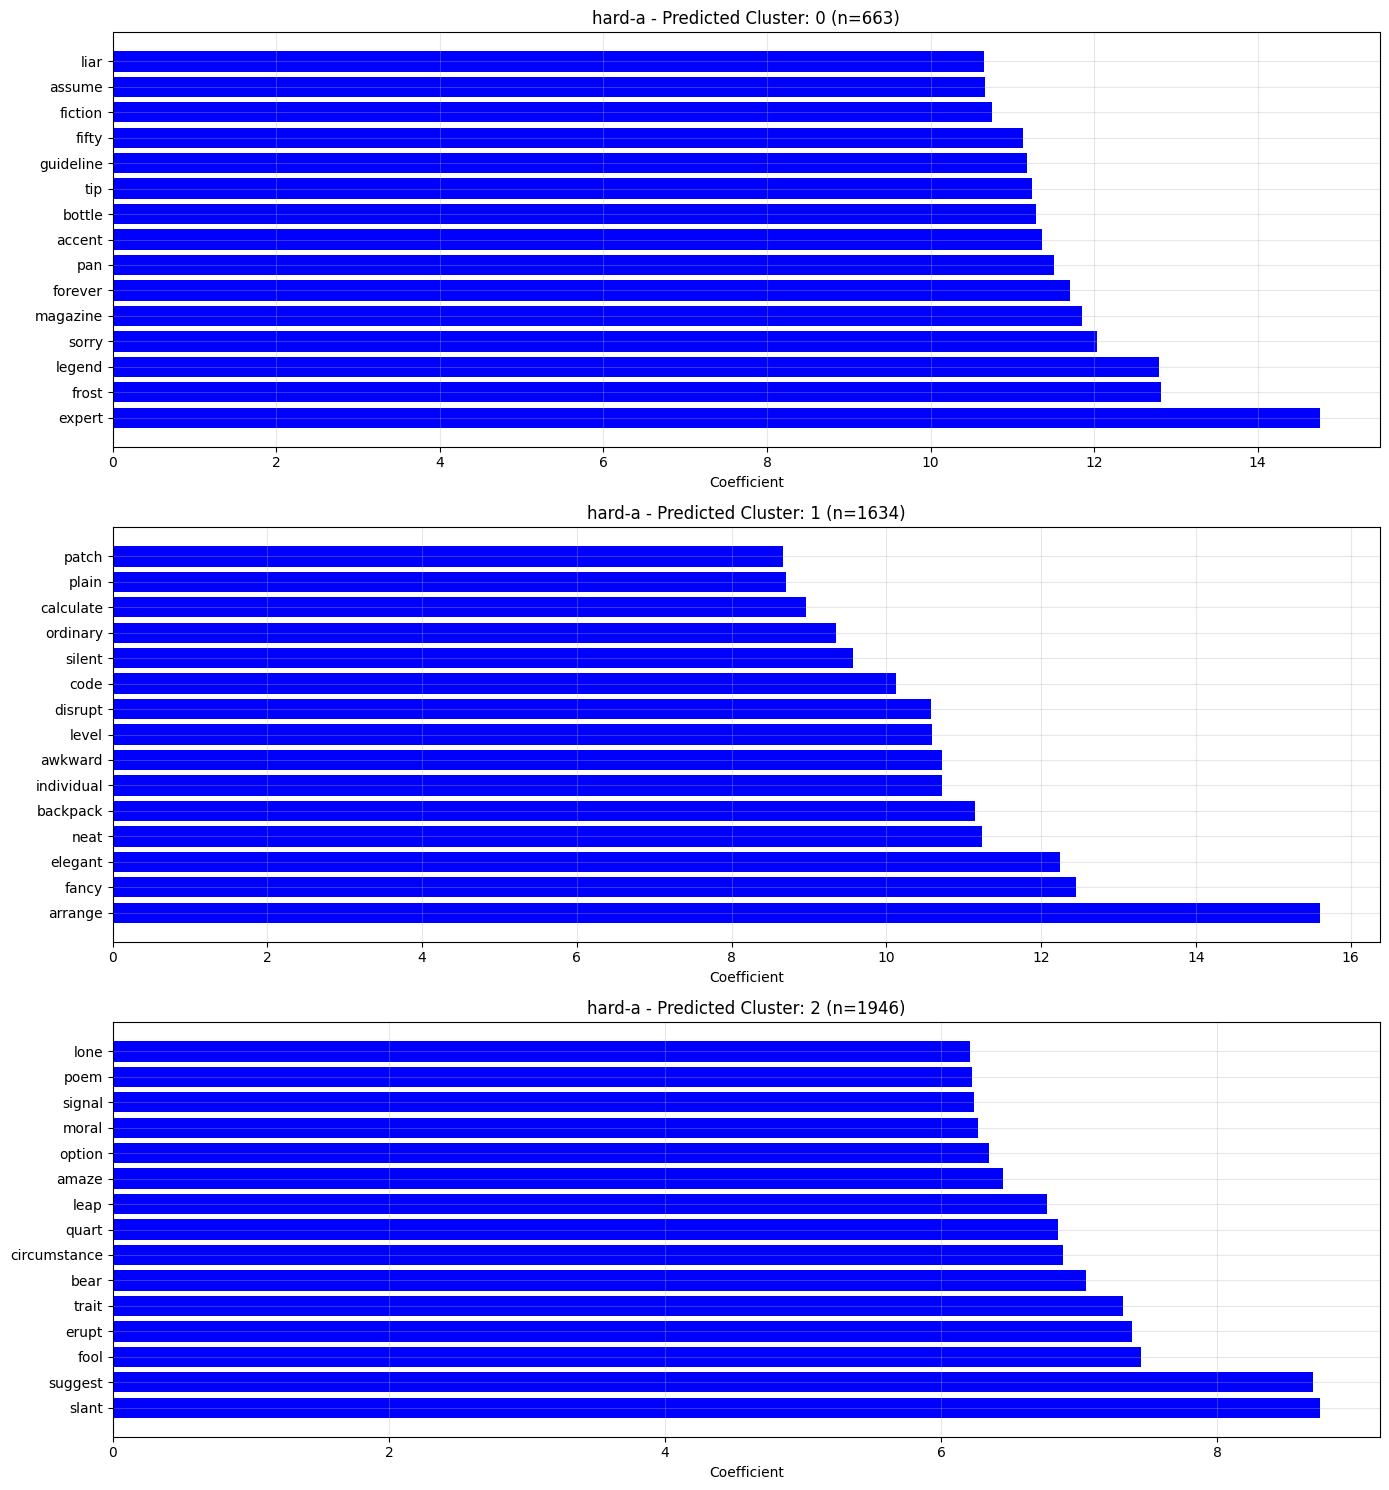

Saved visualization for hard-a


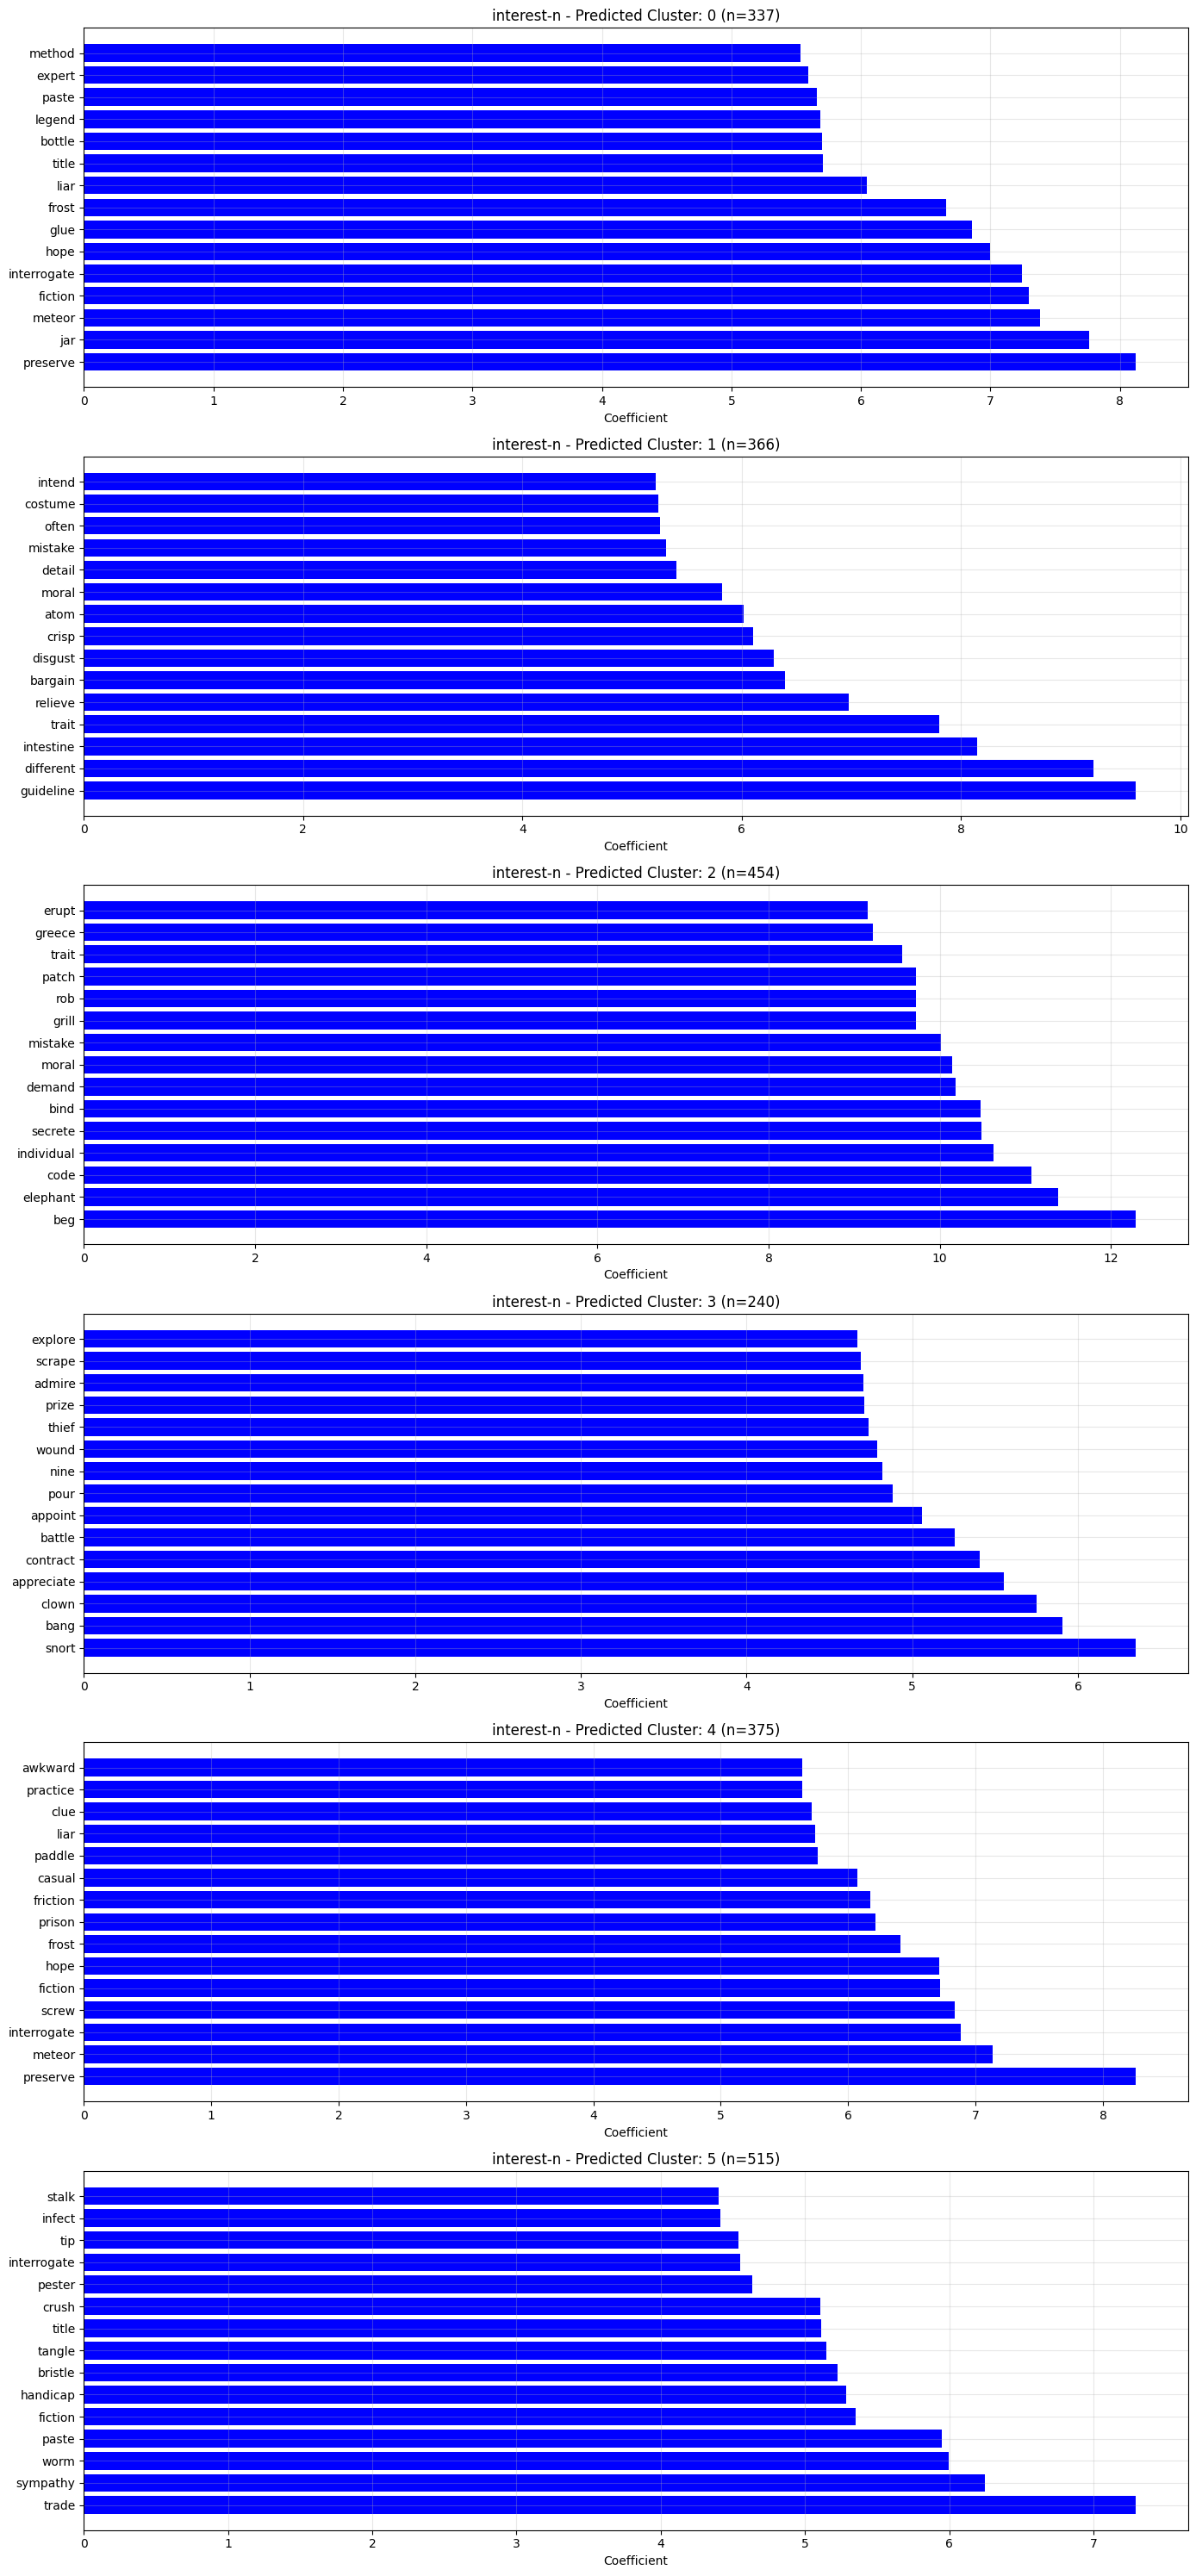

Saved visualization for interest-n


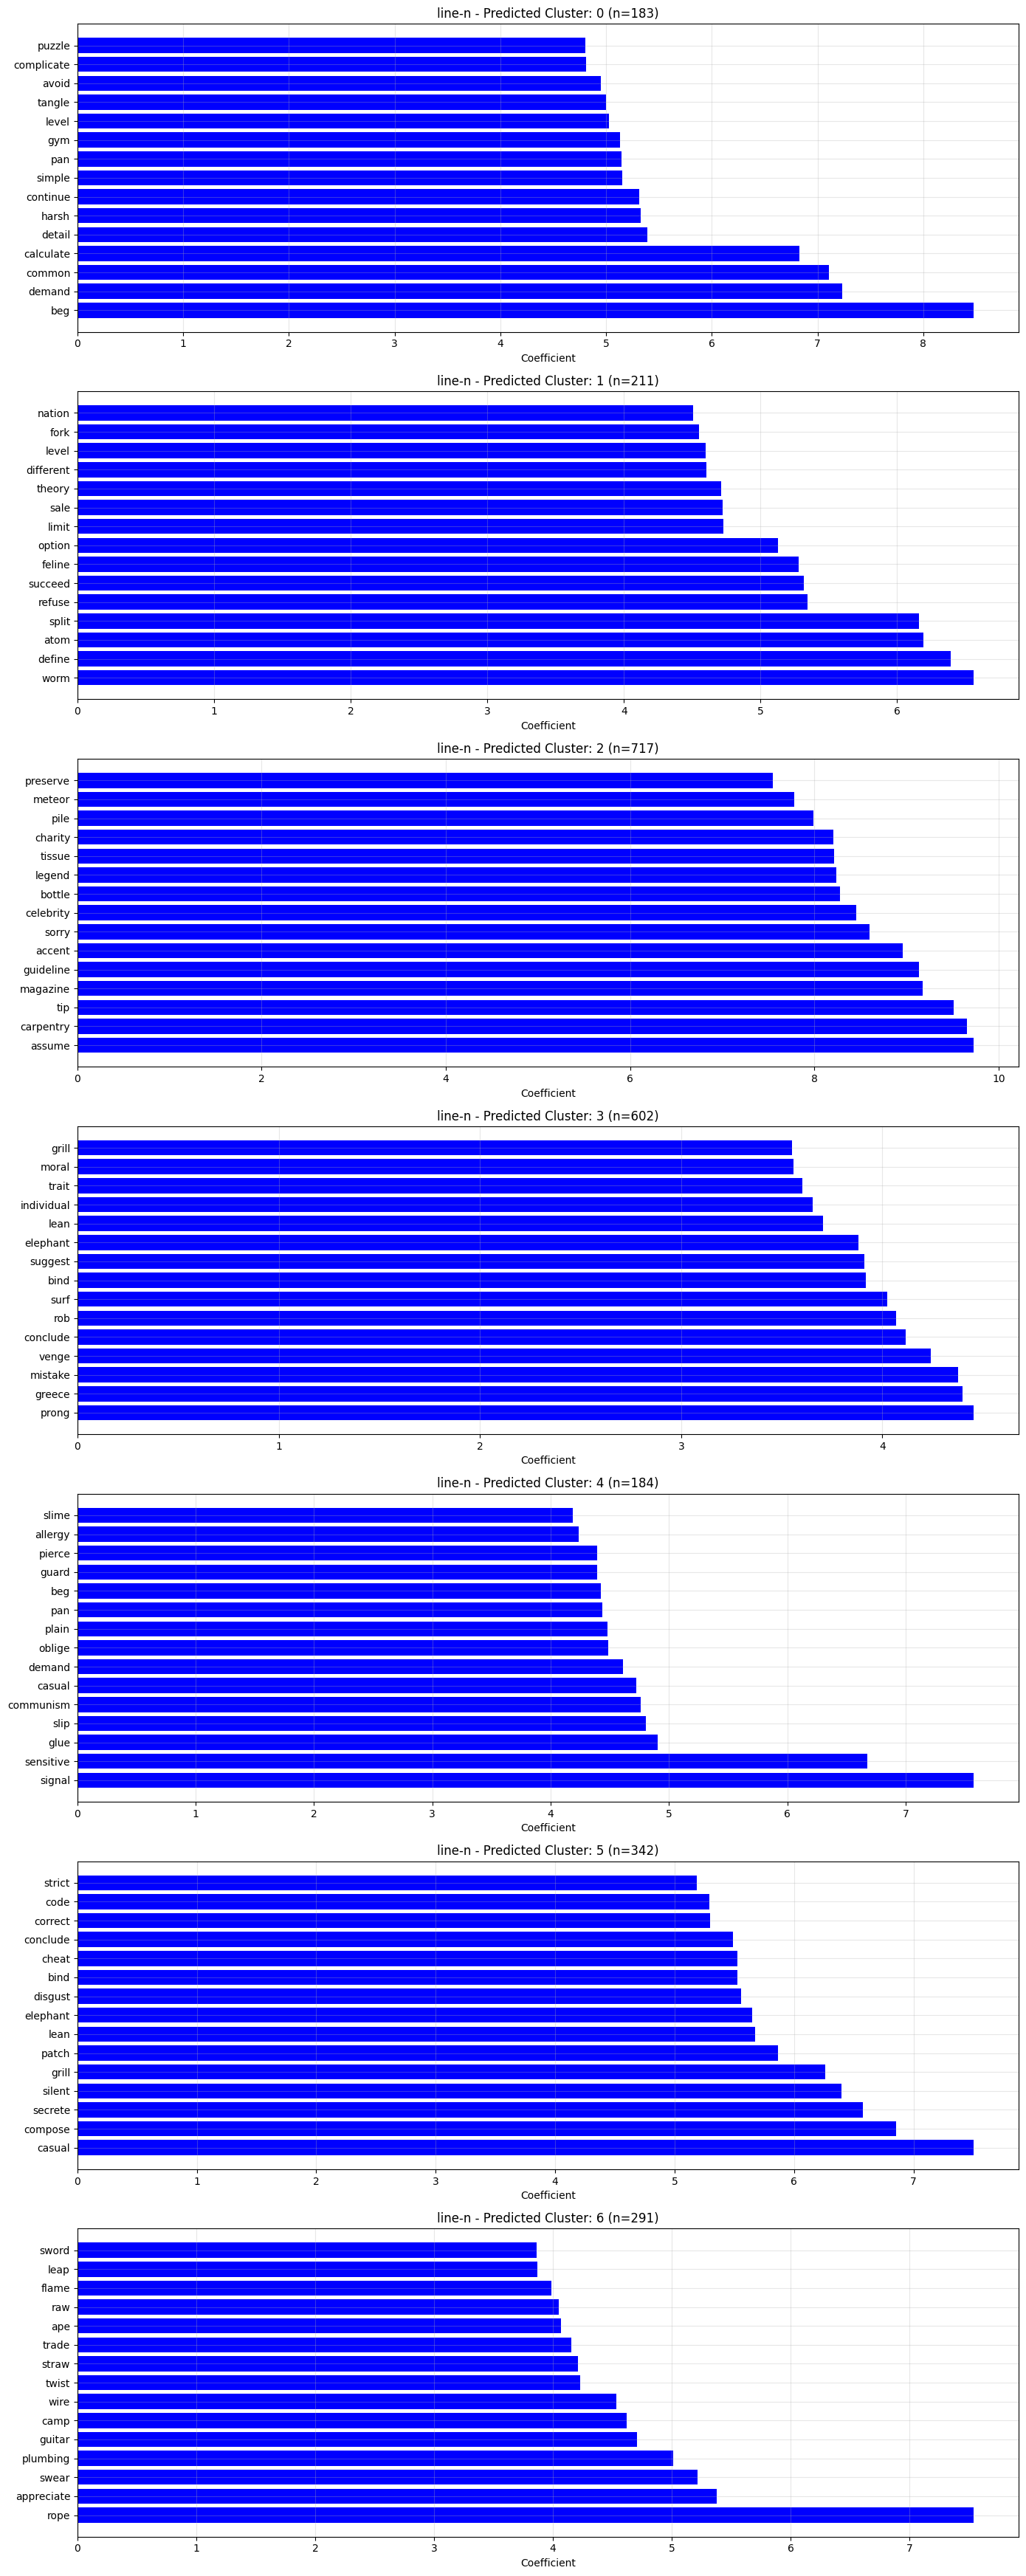

Saved visualization for line-n


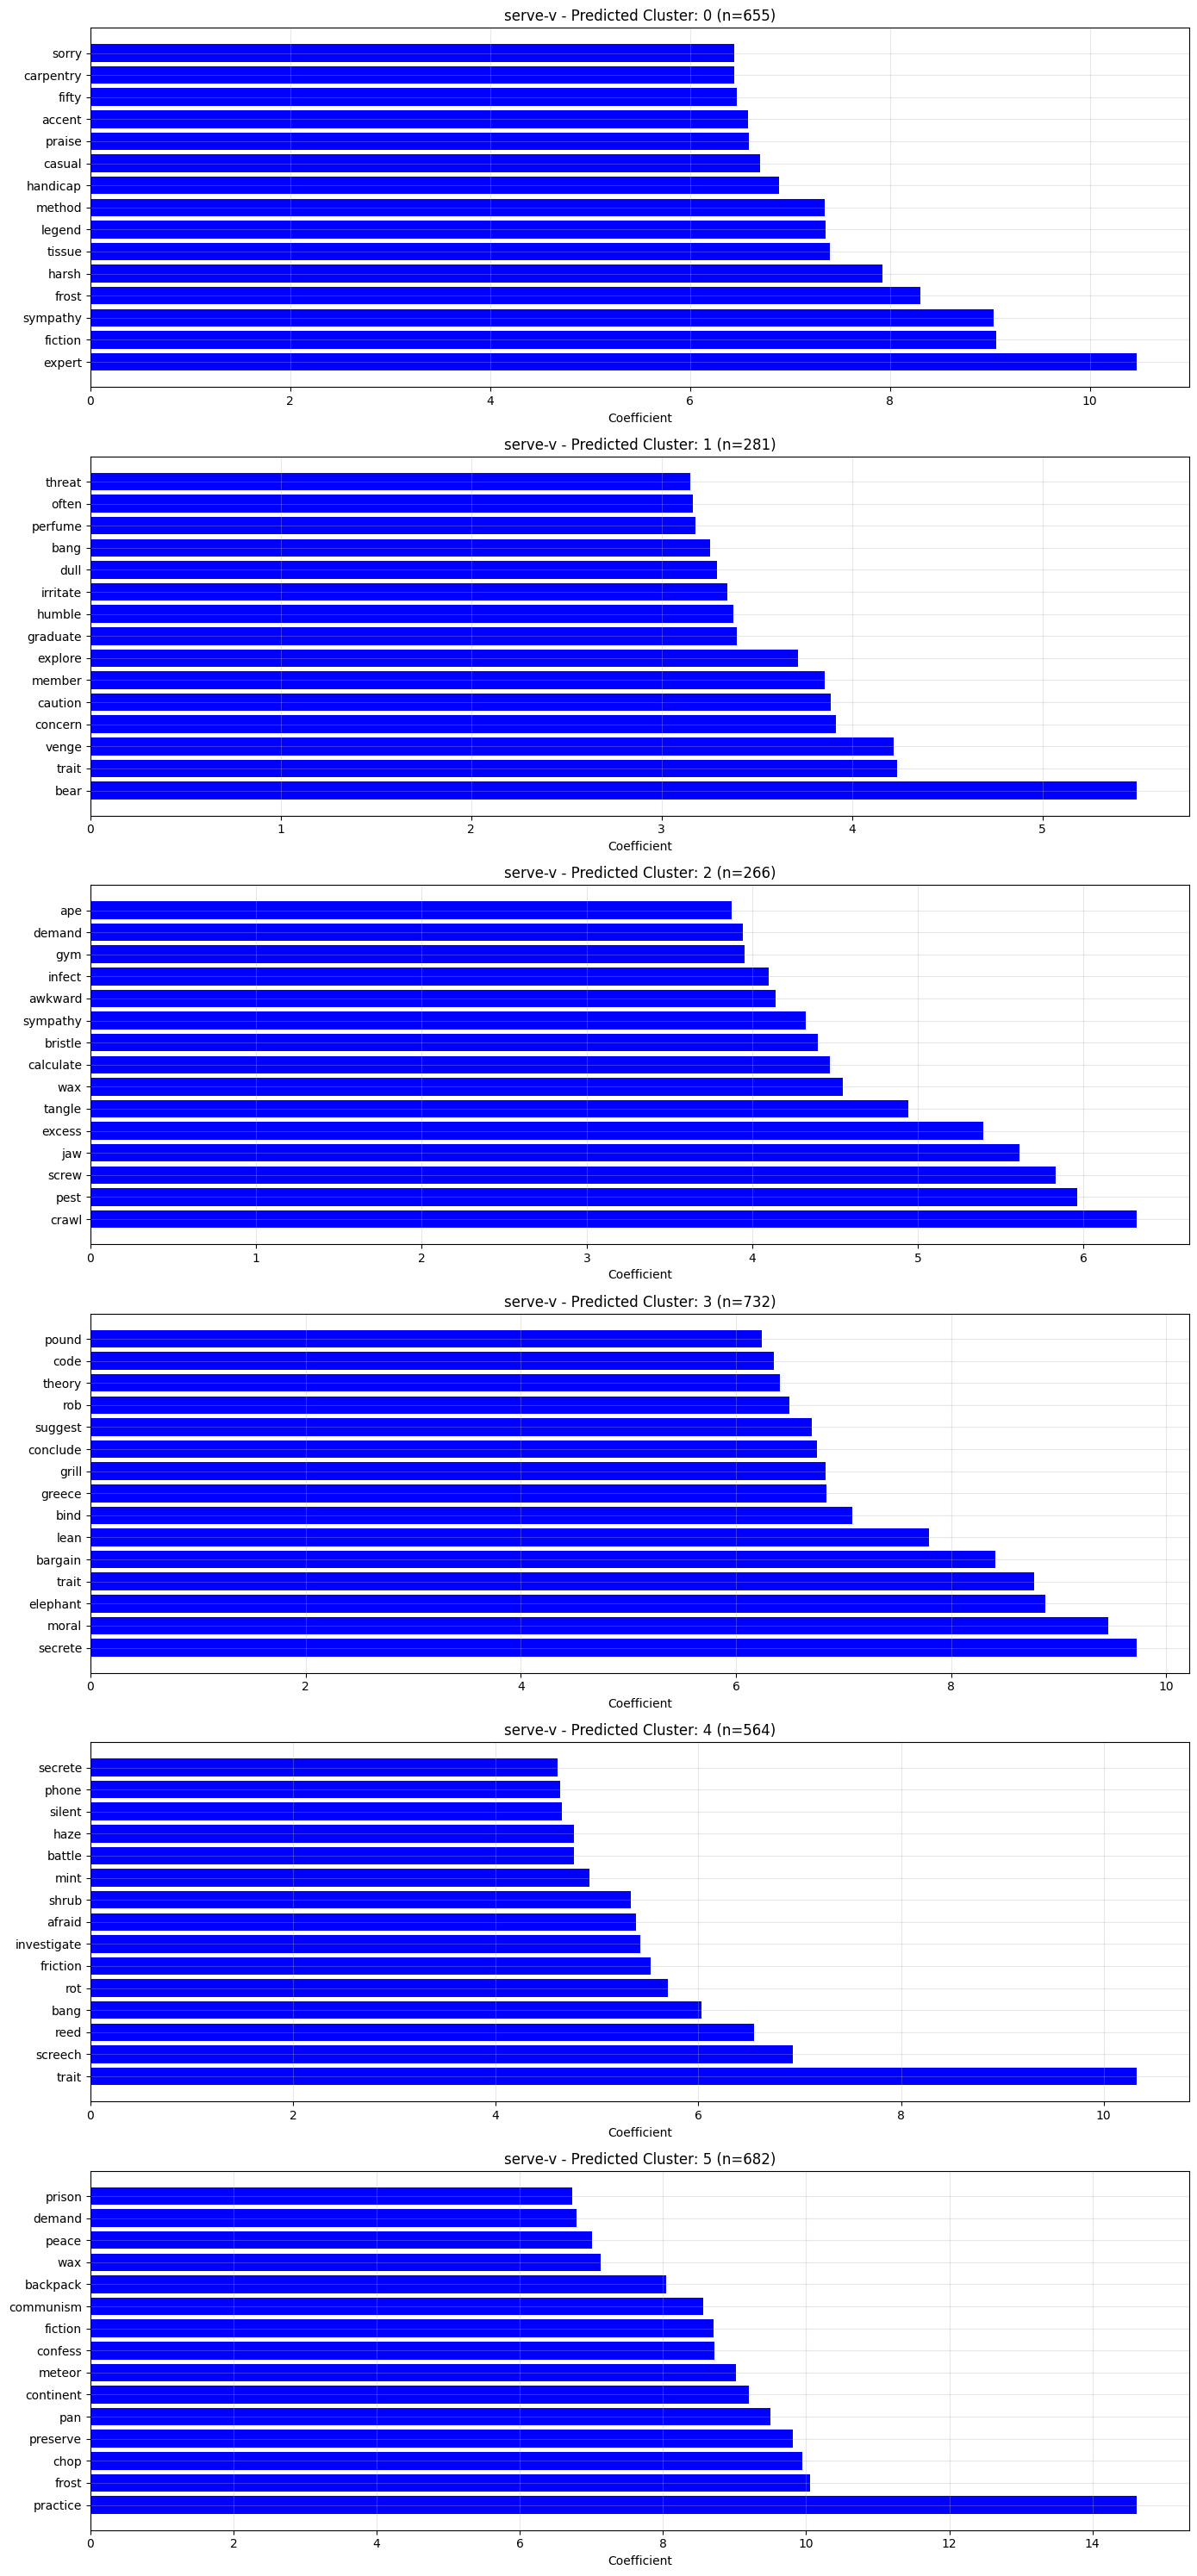

Saved visualization for serve-v


In [ ]:
# Create visualizations for each lemma's predicted clusters
for lemma in all_predicted_results['lemma'].unique():
    lemma_data = all_predicted_results[all_predicted_results['lemma'] == lemma]
    clusters = sorted(lemma_data['cluster'].unique())
    
    # Create a figure with subplots for each cluster
    n_clusters = len(clusters)
    fig, axes = plt.subplots(n_clusters, 1, figsize=(14, 5*n_clusters))
    
    if n_clusters == 1:
        axes = [axes]
    
    for idx, cluster in enumerate(clusters):
        cluster_data = lemma_data[lemma_data['cluster'] == cluster].copy()
        cluster_data['abs_coef'] = cluster_data['coefficient'].abs()
        
        # Get top 15 features
        top_15 = cluster_data.nlargest(15, 'coefficient')
        
        # Create bar plot
        ax = axes[idx]
        colors = ['red' if c < 0 else 'blue' for c in top_15['coefficient']]
        ax.barh(range(len(top_15)), top_15['coefficient'], color=colors)
        ax.set_yticks(range(len(top_15)))
        ax.set_yticklabels(top_15['feature'])
        ax.set_xlabel('Coefficient')
        ax.set_title(f'{lemma} - Predicted Cluster: {cluster} (n={int(top_15.iloc[0]["n_positive"])})')
        ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'/home/gsc685/acl_metapragmatics/pedersen_validation/{lemma}_predicted_clusters_top_features.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"Saved visualization for {lemma}")

## 10. Top Features Summary for Predicted Clusters

In [ ]:
# For each sense, find features with highest predictive accuracy
print("="*80)
print("TOP 10 MOST PREDICTIVE FEATURES BY ACCURACY FOR EACH SENSE")
print("="*80)

for lemma in all_predicted_results['lemma'].unique():
    lemma_data = all_predicted_results[all_predicted_results['lemma'] == lemma]
    
    print(f"\n{lemma.upper()}")
    print("-"*80)
    
    for sense in lemma_data['cluster'].unique():
        sense_data = lemma_data[lemma_data['cluster'] == sense].copy()
        
        # Get top 10 by accuracy
        just_pos = sense_data[sense_data['coefficient'] > 0]
        top_acc = just_pos.nlargest(10, 'accuracy')
        
        print(f"\nSense: {sense} (n={top_acc.iloc[0]['n_positive']})")
        print(top_acc[['feature', 'coefficient', 'accuracy']].to_string(index=False))

# Save top accuracy features to CSV
top_accuracy_features = []

for lemma in all_predicted_results['lemma'].unique():
    lemma_data = all_predicted_results[all_predicted_results['lemma'] == lemma]
    
    for sense in lemma_data['cluster'].unique():
        sense_data = lemma_data[lemma_data['cluster'] == cluster].copy()
        just_pos = sense_data[sense_data['coefficient'] > 0]
        top_10 = sense_data.nlargest(10, 'accuracy')
        
        for idx, row in top_10.iterrows():
            top_accuracy_features.append({
                'lemma': lemma,
                'sense': sense,
                'rank': list(range(1, 11))[list(top_10.index).index(idx)],
                'feature': row['feature'],
                'coefficient': row['coefficient'],
                'accuracy': row['accuracy'],
                'n_samples': row['n_positive']
            })

top_acc_df = pd.DataFrame(top_accuracy_features)
top_acc_df.to_csv('/home/gsc685/acl_metapragmatics/pedersen_validation/pedersen_predicted_clusters_top_accuracy_features.csv', index=False)
print("\n" + "="*80)
print("Top accuracy features saved to: pedersen_validation/pedersen_top_accuracy_features.csv")

TOP 10 MOST PREDICTIVE FEATURES BY ACCURACY FOR EACH SENSE

HARD-A
--------------------------------------------------------------------------------

Sense: 1 (n=1634)
   feature  coefficient  accuracy
complicate     8.421903  0.955220
 challenge     6.013857  0.948857
  ordinary     9.350188  0.938251
     usual     6.737332  0.933538
     level    10.592366  0.929060
  irritate     8.491771  0.915861
   problem     5.209399  0.911619
       odd     6.518701  0.911148
     plain     8.697554  0.893000
     weird     3.616688  0.880509

Sense: 2 (n=1946)
feature  coefficient  accuracy
  silly     3.635500  0.758661
    one     1.256172  0.741221
 mature     2.465334  0.728023
   lift     1.413684  0.725666
    old     1.598671  0.724487
 mental     1.918658  0.720716
 period     2.519706  0.711053
  weigh     0.909347  0.709875
 strong     1.153001  0.708225
    joy     1.454343  0.707754

Sense: 0 (n=663)
feature  coefficient  accuracy
  sweet     1.094605  0.898892
 spread     5.16702

In [ ]:
# Dictionary to store results for predicted clusters
predicted_validation_results = []


for lemma in all_predicted_results['lemma'].unique():
    lemma_data = all_predicted_results[all_predicted_results['lemma'] == lemma]
    
    print(f"\n{lemma.upper()}")
    print("-"*80)
    
    for cluster in sorted(lemma_data['cluster'].unique()):
        cluster_data = lemma_data[lemma_data['cluster'] == cluster].copy()

    
    # 1. Load features for this lemma
    features_path = f'/home/gsc685/data/features/senseval2/{lemma}_feature_vectors_roberta_buchanan_layer7.csv'
    features_df = pd.read_csv(features_path)
    print(f"Loaded {len(features_df)} feature rows")
    
    # 2. Get subset of pedersen_df for this lemma (to align data)
    lemma_data = pedersen_df[pedersen_df['word'] == lemma].copy()
    print(f"Found {len(lemma_data)} instances in pedersen_df")
    
    # 3. Transform features into feature vectors (pivot wide format)
    print(f"\nTransforming to feature vectors...")
    feature_matrix = features_df.pivot(index='token_id', columns='feature', values='predicted_value')
    print(f"Feature matrix shape: {feature_matrix.shape}")
    
    # 4. Ensure we have matching data
    common_token_ids = set(feature_matrix.index) & set(lemma_data['token_id'])
    print(f"Common tokens between features and gold data: {len(common_token_ids)}")
    
    # Filter both dataframes
    feature_matrix_filtered = feature_matrix.loc[list(common_token_ids)].sort_index()
    lemma_data_filtered = lemma_data[lemma_data['token_id'].isin(common_token_ids)].sort_values('token_id')
    
    # 5. Run K-means clustering
    k = k_values[lemma]
    print(f"\nRunning K-means with k={k}...")
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    predicted_clusters = kmeans.fit_predict(feature_matrix_filtered)
    
    # Add predicted clusters to lemma_data
    lemma_data_filtered['predicted_cluster'] = predicted_clusters
    
    # Show cluster distribution
    cluster_counts = pd.Series(predicted_clusters).value_counts().sort_index()
    print(f"Predicted cluster distribution:")
    print(cluster_counts)
    
    # 6. Regressions - for each predicted cluster, find most predictive features
    from sklearn.linear_model import LinearRegression
    from scipy import stats
    
    # Store regression results
    regression_results = []
    
    for cluster in range(k):
        print(f"\nAnalyzing features for cluster: {cluster}")
        
        # Create binary predictor: 1 if token belongs to this cluster, 0 otherwise
        X = (predicted_clusters == cluster).astype(int).reshape(-1, 1)
        
        # For each feature, regress feature values on cluster membership
        for feature_name in feature_matrix_filtered.columns:
            # Get feature values as dependent variable
            y = feature_matrix_filtered[feature_name].values
            
            # Check if feature has variance
            if y.std() == 0:
                continue
            
            # Fit linear regression: y (feature value) ~ X (cluster membership)
            try:
                lr = LinearRegression()
                lr.fit(X, y)
                
                # Get coefficient and R-squared
                coef = lr.coef_[0]
                r2_score = lr.score(X, y)
                
                # Calculate t-statistic and p-value
                n = len(y)
                y_pred = lr.predict(X)
                residuals = y - y_pred
                mse = np.sum(residuals**2) / (n - 2)
                var_X = np.var(X, ddof=1)
                se_coef = np.sqrt(mse / (var_X * n))
                t_stat = coef / se_coef if se_coef > 0 else 0
                p_value = 2 * (1 - stats.t.cdf(abs(t_stat), n - 2))
                
                # Store result
                regression_results.append({
                    'lemma': lemma,
                    'cluster': cluster,
                    'feature': feature_name,
                    'coefficient': coef,
                    'r_squared': r2_score,
                    't_statistic': t_stat,
                    'p_value': p_value,
                    'n_samples': len(y),
                    'n_in_cluster': X.sum()
                })
            except Exception as e:
                print(f"Error with feature {feature_name}: {e}")
                continue
    
    # Convert results to dataframe for this lemma
    if regression_results:
        lemma_results_df = pd.DataFrame(regression_results)
        
        # For each cluster, show top 10 most predictive features (by absolute coefficient)
        print(f"\n{'='*60}")
        print(f"Top 10 features for each cluster of {lemma}:")
        print(f"{'='*60}")
        
        for cluster in range(k):
            cluster_results = lemma_results_df[lemma_results_df['cluster'] == cluster].copy()
            cluster_results['abs_coef'] = cluster_results['coefficient'].abs()
            top_features = cluster_results.nlargest(10, 'abs_coef')
            
            print(f"\nCluster: {cluster} (n={int(top_features.iloc[0]['n_in_cluster'])})")
            print(top_features[['feature', 'coefficient', 'r_squared', 'p_value']].to_string(index=False))
        
        # Save results
        predicted_validation_results.append(lemma_results_df)
